# Fake multimodal

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
exp = "simulated_multimodal"
results_path = f"/home/mila/m/myriam.lizotte/scratch/RF-MALI/results/{exp}"

# load results
results_df = pd.read_csv(f"{results_path}/{exp}_results.csv")

# in the df, replace "_" with " " 
results_df['split'] = results_df['split'].str.replace('_', ' ')
results_df.columns = results_df.columns.str.replace('_', ' ')
results_df['model'] = results_df['model'].str.replace('RFMALI_WIP', 'FoSTA')


# # convert relevant columns to numeric
num_cols = results_df.columns.difference(['model', 'dataset', 'split', 'seed'])
# results_df[num_cols] = results_df[num_cols].apply(pd.to_numeric, errors='coerce')


# take the abs for silhouette domain because it should be low, doesnt matter the sign
results_df['Silhouette domain'] = results_df['Silhouette domain'].abs()

results_df

,seed,split,dataset,model,FOSCTTM,Silhouette domain,Accuracy missing,Accuracy visible,Alignment score
0,29501205,rotate,hepatitis,RFMALI,0.247514,0.002040,0.695652,0.840580,0.926812
1,29501205,rotate,hepatitis,FoSTA,0.247540,0.004512,0.724638,0.826087,0.870290
2,29501205,rotate,hepatitis,MALI,0.116973,0.005683,0.608696,0.811594,1.037681
3,29501205,rotate,hepatitis,Pamona,0.000079,0.007215,0.710145,0.811594,1.100000
4,29501205,rotate,hepatitis,KEMArbf,0.488416,0.489627,0.507246,0.594203,0.018841
...,...,...,...,...,...,...,...,...,...
487,41184989,add noise features,tic-tac-toe,FoSTA,0.361208,0.103224,0.805846,0.862213,0.108834
488,41184989,add noise features,tic-tac-toe,MALI,0.409450,0.009489,0.749478,0.772443,0.902923
489,41184989,add noise features,tic-tac-toe,Pamona,0.494835,0.003033,0.659708,0.603340,0.981870
490,41184989,add noise features,tic-tac-toe,KEMArbf,0.500396,0.525301,0.359081,0.334029,0.012251


average over all datasets

In [3]:
summary_df = results_df.groupby(['split','model'])[num_cols].mean()
summary_df_std = results_df.groupby(['split','model'])[num_cols].std()
summary_df

Accuracy missing  Accuracy visible  \
split                  model                                         
add noise features     FoSTA            0.765704          0.850326   
                       KEMAlin          0.595408          0.594340   
                       KEMArbf          0.513484          0.676141   
                       MALI             0.713393          0.733391   
                       Pamona           0.638895          0.635621   
                       RFMALI           0.767764          0.835803   
alternating importance FoSTA            0.772471          0.850649   
                       KEMAlin          0.480893          0.494041   
                       KEMArbf          0.507511          0.572451   
                       MALI             0.636880          0.656279   
                       Pamona           0.633575          0.646339   
                       RFMALI           0.764915          0.855797   
distort                FoSTA            0.781553          0.874275   
                       KEMAlin          0.588351          0.602645   
                       KEMArbf          0.541357          0.629808   
                       MALI             0.726331          0.755801   
                       Pamona           0.678260          0.696404   
                       RFMALI           0.784648          0.873510   
importance             FoSTA            0.788939          0.833972   
                       KEMAlin          0.498721          0.508540   
                       KEMArbf          0.488866          0.561487   
                       MALI             0.630779          0.593244   
                       Pamona           0.717411          0.683625   
                       RFMALI           0.786815          0.831916   
random                 FoSTA            0.746640          0.839253   
                       KEMAlin          0.601316          0.626640   
                       KEMArbf          0.497677          0.577984   
                       MALI             0.603811          0.629600   
                       Pamona           0.636897          0.650133   
                       RFMALI           0.752303          0.836212   
rotate                 FoSTA            0.809246          0.909158   
                       KEMAlin          0.598949          0.622179   
                       KEMArbf          0.467415          0.642339   
                       MALI             0.733755          0.762191   
                       Pamona           0.756093          0.760825   
                       RFMALI           0.807753          0.908770   

                                Alignment score   FOSCTTM  Silhouette domain  
split                  model                                                  
add noise features     FoSTA           0.388497  0.223284           0.043822  
                       KEMAlin         0.001175  0.442694           0.585898  
                       KEMArbf         0.018053  0.444369           0.526219  
                       MALI            0.933313  0.340396           0.004594  
                       Pamona          0.718274  0.430022           0.016367  
                       RFMALI          0.348949  0.219624           0.038413  
alternating importance FoSTA           0.720333  0.313054           0.004944  
                       KEMAlin         0.034577  0.460753           0.452567  
                       KEMArbf         0.029676  0.462307           0.450996  
                       MALI            0.982189  0.375162           0.003340  
                       Pamona          0.490168  0.394222           0.009943  
                       RFMALI          0.759148  0.310001           0.001957  
distort                FoSTA           0.757155  0.216006           0.012293  
                       KEMAlin         0.021329  0.444060           0.484898  
                       KEMArbf         0.029629  0.453264           0.480659  
                       MALI 

In [4]:
summary_df_std

Accuracy missing  Accuracy visible  \
split                  model                                         
add noise features     FoSTA            0.157990          0.117993   
                       KEMAlin          0.184160          0.179325   
                       KEMArbf          0.199146          0.207698   
                       MALI             0.162181          0.137328   
                       Pamona           0.230366          0.197139   
                       RFMALI           0.162692          0.128904   
alternating importance FoSTA            0.150936          0.110122   
                       KEMAlin          0.220760          0.208381   
                       KEMArbf          0.192276          0.172823   
                       MALI             0.193415          0.175710   
                       Pamona           0.206919          0.189428   
                       RFMALI           0.154748          0.116992   
distort                FoSTA            0.132439          0.114411   
                       KEMAlin          0.197125          0.201103   
                       KEMArbf          0.195084          0.195045   
                       MALI             0.170438          0.167284   
                       Pamona           0.190350          0.188447   
                       RFMALI           0.131495          0.120711   
importance             FoSTA            0.129595          0.112782   
                       KEMAlin          0.191384          0.178174   
                       KEMArbf          0.160274          0.172100   
                       MALI             0.171698          0.192721   
                       Pamona           0.218649          0.255666   
                       RFMALI           0.133774          0.115305   
random                 FoSTA            0.131633          0.106163   
                       KEMAlin          0.185118          0.164520   
                       KEMArbf          0.187080          0.165849   
                       MALI             0.200643          0.195427   
                       Pamona           0.186863          0.168064   
                       RFMALI           0.139199          0.101631   
rotate                 FoSTA            0.134009          0.078769   
                       KEMAlin          0.217659          0.190920   
                       KEMArbf          0.199963          0.204937   
                       MALI             0.215520          0.216286   
                       Pamona           0.190661          0.187041   
                       RFMALI           0.129108          0.081145   

                                Alignment score   FOSCTTM  Silhouette domain  
split                  model                                                  
add noise features     FoSTA           0.154487  0.101696           0.036478  
                       KEMAlin         0.001768  0.092205           0.096258  
                       KEMArbf         0.010995  0.074283           0.143422  
                       MALI            0.056247  0.084765           0.004195  
                       Pamona          0.199242  0.081522           0.012623  
                       RFMALI          0.170303  0.108387           0.037371  
alternating importance FoSTA           0.210347  0.124928           0.009755  
                       KEMAlin         0.046141  0.062147           0.119301  
                       KEMArbf         0.039374  0.050746           0.082736  
                       MALI            0.112674  0.143337           0.002653  
                       Pamona          0.295488  0.177159           0.010047  
                       RFMALI          0.189593  0.127378           0.001498  
distort                FoSTA           0.210984  0.072982           0.018987  
                       KEMAlin         0.045769  0.080185           0.125347  
                       KEMArbf         0.035124  0.059248           0.107702  
                       MALI 

# print it to a table

subset to the methods/metrics we want

In [5]:
# clean summary_df 

def clean_summary_df(df):
    # remove "RFMALI" 
    df = df.loc[df.index.get_level_values('model') != 'RFMALI']

    cols_to_keep = ["Accuracy missing", "Alignment score", "FOSCTTM"]
    # rename Accuracy missing to Accuracy
    df = df[cols_to_keep]
    df = df.rename(columns={"Accuracy missing": "Accuracy"})
    return df

summary_df = clean_summary_df(summary_df)
summary_df_std = clean_summary_df(summary_df_std)

In [6]:
# Function to format the top 3 values: bold, underline, italic (adjusted for lower is better columns)
def format_top_3(df):
    formatted_df = df.copy()
    
    # List of columns where lower values are better
    lower_is_better_columns = ['FOSCTTM', 'Silhouette domain']
    
    # Group by 'split' to format the top 3 values in each split
    for split, group in df.groupby('split'):
        for column in group.columns:  # Start from the first numerical column
            if column in lower_is_better_columns:
                # Find the smallest 3 values (lower is better)
                top_3 = group[column].nsmallest(3).values
            else:
                # Find the largest 3 values (higher is better)
                top_3 = group[column].nlargest(3).values
            
            if len(top_3) >= 3:
                # Apply formatting: bold for best, underline for second, italic for third
                formatted_df.loc[group.index, column] = group[column].apply(
                    lambda x: f"\\textbf{{{x:.3f}}}" if x == top_3[0] else 
                              (f"\\underline{{{x:.3f}}}" if x == top_3[1] else 
                               (f"\\textit{{{x:.3f}}}" if x == top_3[2] else f"{x:.3f}"))
                )
    
    return formatted_df

In [11]:
summary_df_fmt = format_top_3(summary_df)


/tmp/ipykernel_3760867/3071777113.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['\\textbf{0.766}' '0.595' '0.513' '\\underline{0.713}' '\\textit{0.639}']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted_df.loc[group.index, column] = group[column].apply(
/tmp/ipykernel_3760867/3071777113.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['\\textit{0.388}' '0.001' '0.018' '\\textbf{0.933}' '\\underline{0.718}']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted_df.loc[group.index, column] = group[column].apply(
/tmp/ipykernel_3760867/3071777113.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['\\textbf{0.223}' '0.443' '0.444'

In [ ]:
# add std

# for col in summary_df.columns:
#     summary_df_fmt[col] = (
#         summary_df[col].round(3).astype(str)
#         + r" {\small $\pm$ "
#         + summary_df_std[col].round(3).astype(str)
#         + "}"
#     )

In [12]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    print(summary_df_fmt.to_latex(
        escape=False,
        multirow=True,
        float_format="%.3f"
    )) 

# then copy the output latex table into a .tex file for inclusion in the paper

\begin{tabular}{lllll}
\toprule
 &  & Accuracy & Alignment score & FOSCTTM \\
split & model &  &  &  \\
\midrule
\multirow[t]{5}{*}{add noise features} & FoSTA & \textbf{0.766} & \textit{0.388} & \textbf{0.223} \\
 & KEMAlin & 0.595 & 0.001 & 0.443 \\
 & KEMArbf & 0.513 & 0.018 & 0.444 \\
 & MALI & \underline{0.713} & \textbf{0.933} & \underline{0.340} \\
 & Pamona & \textit{0.639} & \underline{0.718} & \textit{0.430} \\
\cline{1-5}
\multirow[t]{5}{*}{alternating importance} & FoSTA & \textbf{0.772} & \underline{0.720} & \textbf{0.313} \\
 & KEMAlin & 0.481 & 0.035 & 0.461 \\
 & KEMArbf & 0.508 & 0.030 & 0.462 \\
 & MALI & \underline{0.637} & \textbf{0.982} & \underline{0.375} \\
 & Pamona & \textit{0.634} & \textit{0.490} & \textit{0.394} \\
\cline{1-5}
\multirow[t]{5}{*}{distort} & FoSTA & \textbf{0.782} & \textit{0.757} & \textbf{0.216} \\
 & KEMAlin & 0.588 & 0.021 & 0.444 \\
 & KEMArbf & 0.541 & 0.030 & 0.453 \\
 & MALI & \underline{0.726} & \textbf{0.980} & \textit{0.256} \\
 & P

# bar plots

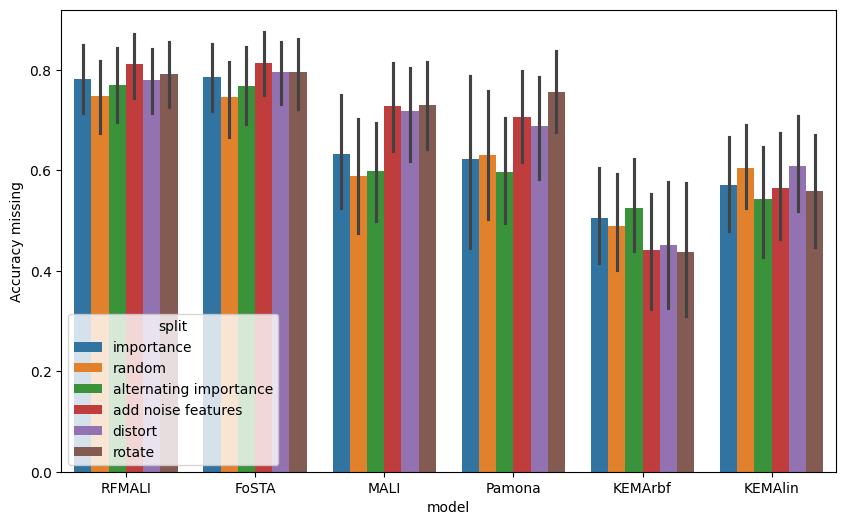

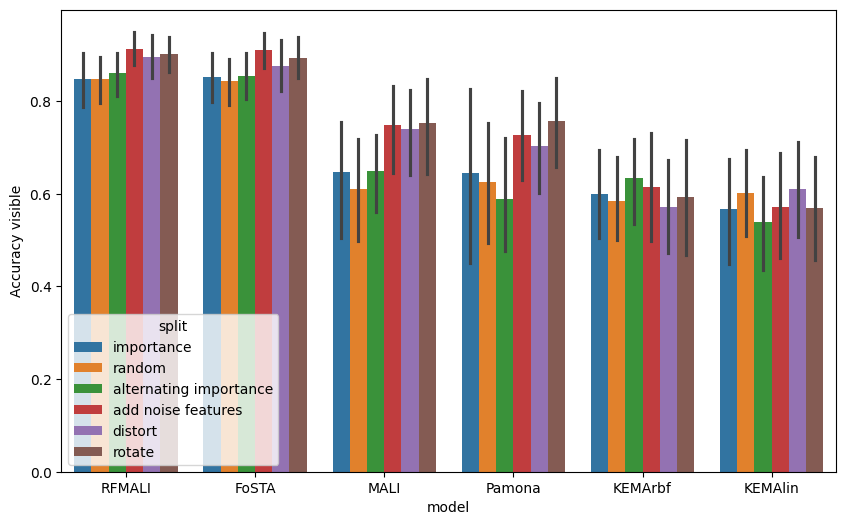

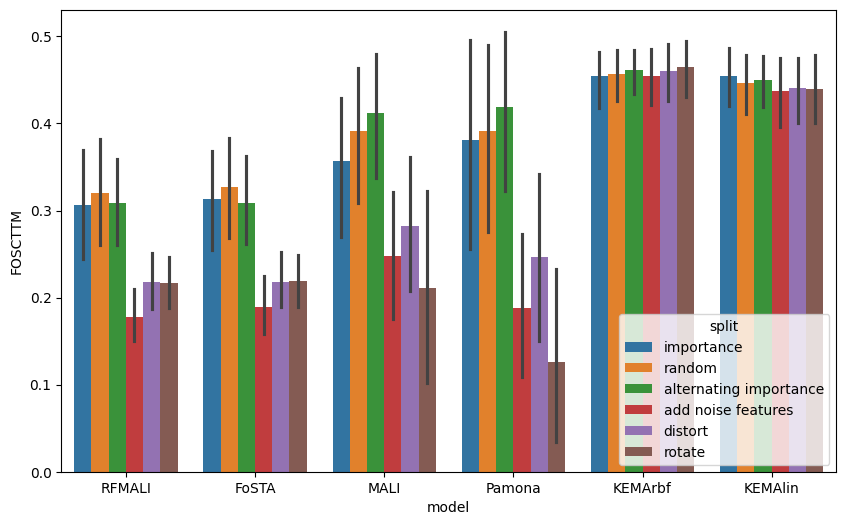

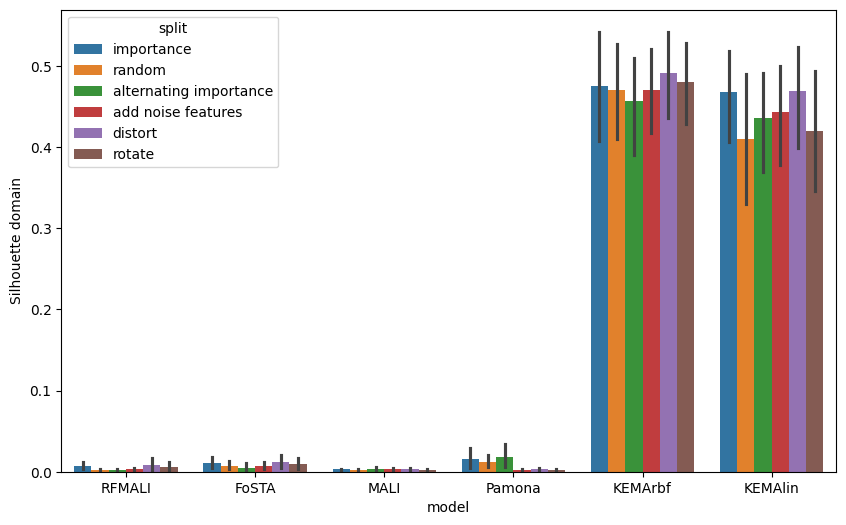

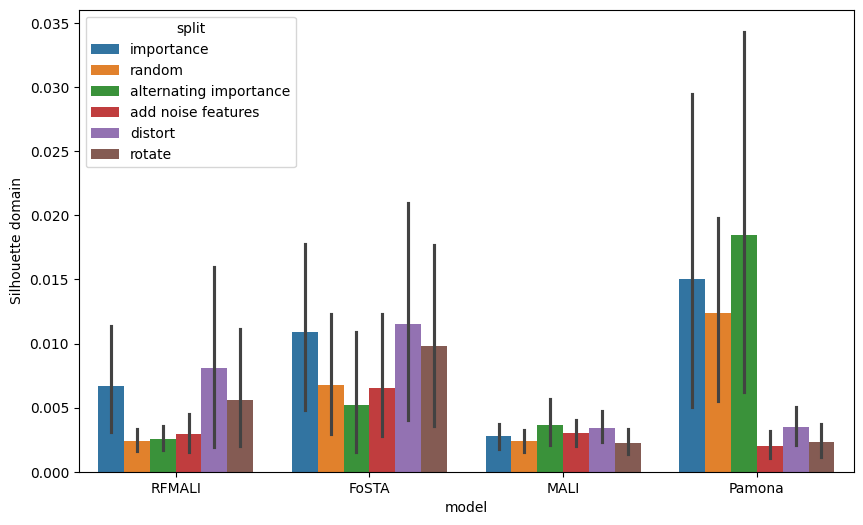

In [ ]:
for col in num_cols:
    plt.figure(figsize=(10,6))
    sns.barplot(data=results_df, x='model', y=col, hue='split')
    
    if col == "Silhouette domain":
        plt.figure(figsize=(10,6))
        sns.barplot(data=results_df[(results_df['model'] != "KEMArbf") & (results_df['model'] != "KEMAlin")], x='model', y=col, hue='split')
        plt.show()

# grouped by split

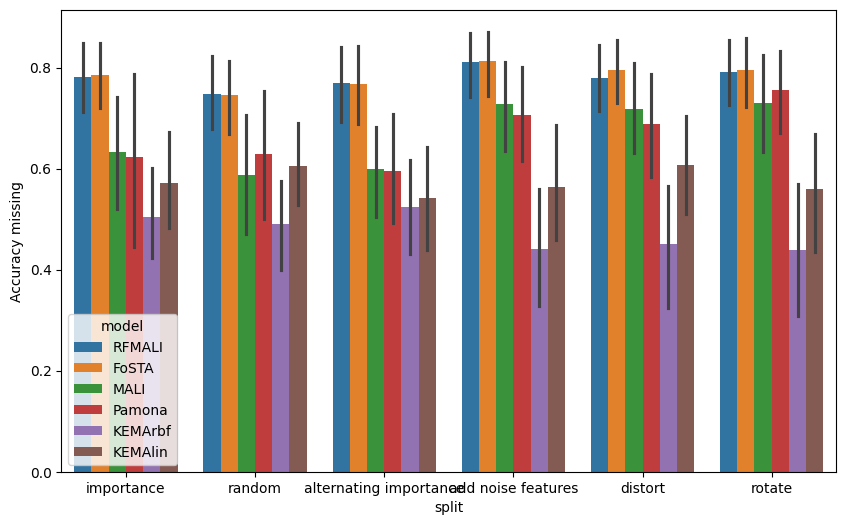

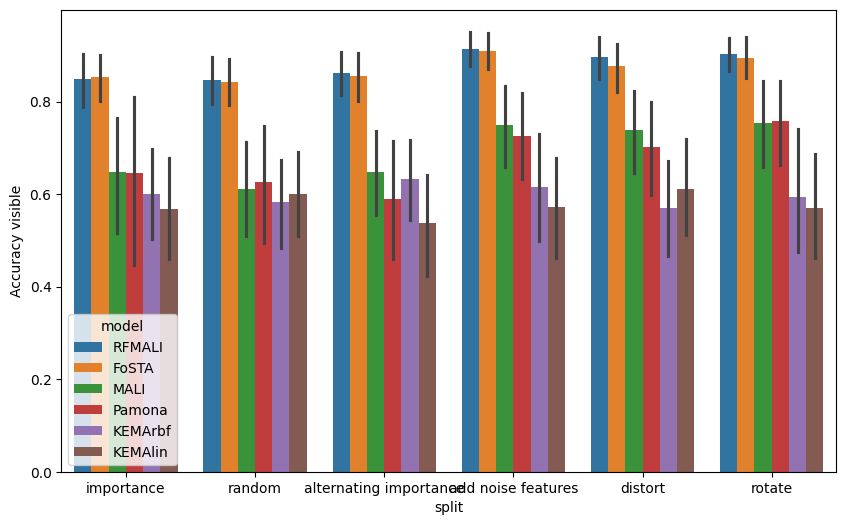

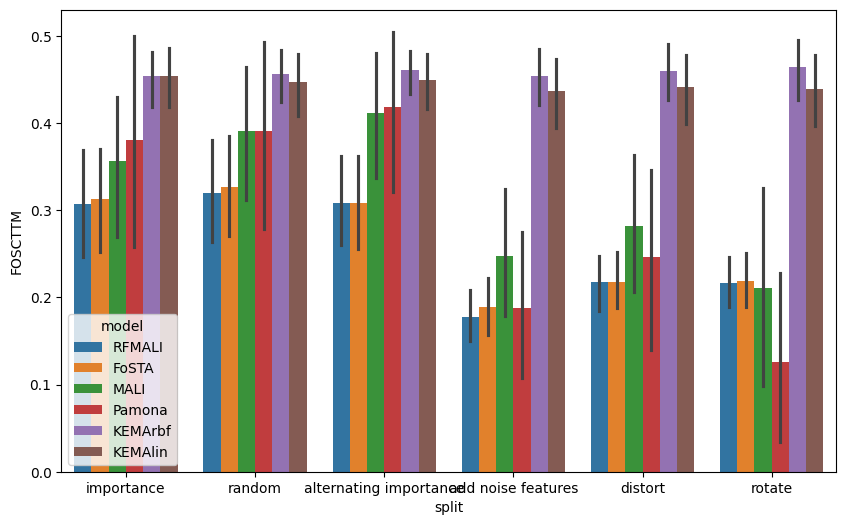

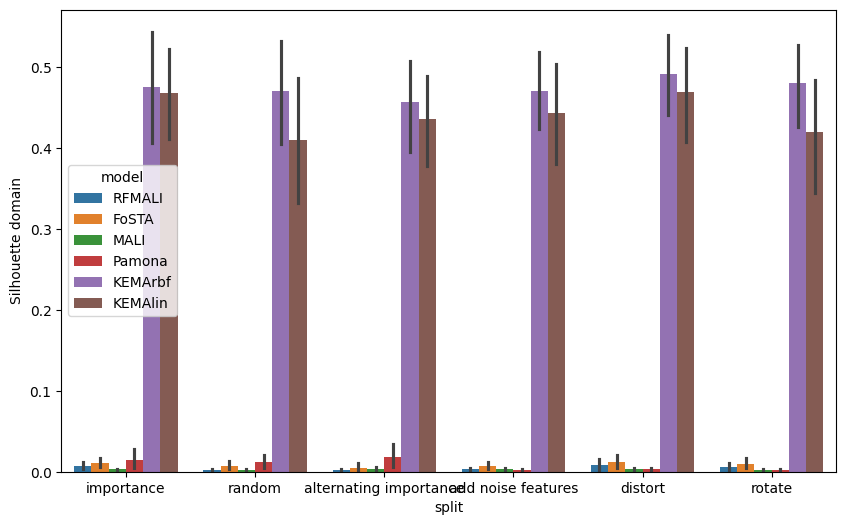

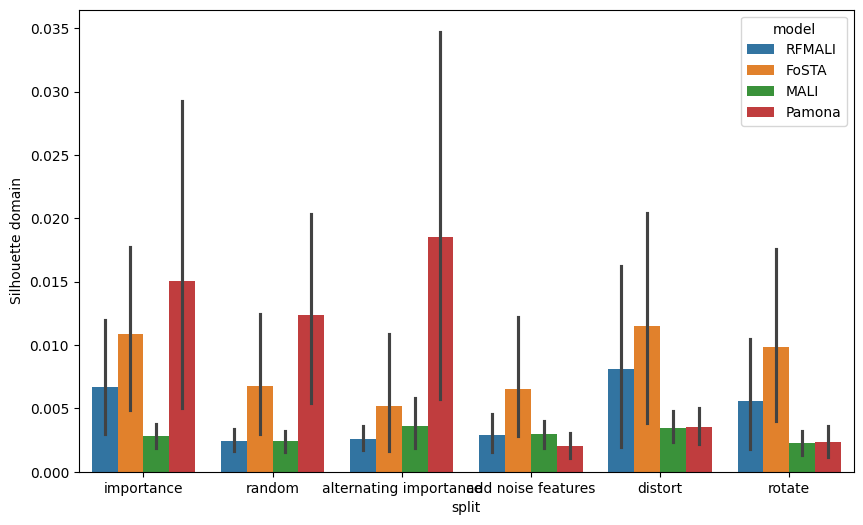

In [ ]:
for col in num_cols:
    plt.figure(figsize=(10,6))
    sns.barplot(data=results_df, x='split', y=col, hue='model')
    
    if col == "Silhouette domain":
        plt.figure(figsize=(10,6))
        sns.barplot(data=results_df[(results_df['model'] != "KEMArbf") & (results_df['model'] != "KEMAlin")], x='split', y=col, hue='model')
        plt.show()

# checking the failed runs

In [ ]:
nas = results_df[results_df['Silhouette domain'].isna()][['split', 'dataset', 'model']]
nas

,split,dataset,model
2,importance,balance_scale,MALI
3,importance,balance_scale,Pamona
8,random,breast_cancer,MALI
9,random,breast_cancer,Pamona
14,importance,crx,MALI
15,importance,crx,Pamona
20,alternating importance,breast_cancer,MALI
21,alternating importance,breast_cancer,Pamona
27,alternating importance,balance_scale,Pamona
33,random,balance_scale,Pamona


In [ ]:
print(nas['split'].value_counts())
print(nas['dataset'].value_counts())
print(nas['model'].value_counts())

split
random                    47
importance                45
alternating importance    45
add noise features        43
Name: count, dtype: int64
dataset
flare1           16
balance_scale    15
breast_cancer    14
tic-tac-toe      14
crx              13
hepatitis        12
parkinsons       12
seeds            12
glass            12
iris             12
ionosphere       12
heart_disease    12
heart_failure    12
diabetes         12
Name: count, dtype: int64
model
RFMALI    56
FoSTA     56
MALI      56
Pamona    12
Name: count, dtype: int64


In [ ]:
datasets_path = "/home/mila/m/myriam.lizotte/scratch/rf-autoencoders/data"
data_name = "breast_cancer"
df = pd.read_csv(f"{datasets_path}/{data_name}.csv")

In [ ]:
import sys, pathlib
sys.path.insert(0, str(next(p for p in [pathlib.Path.cwd()] + list(pathlib.Path.cwd().parents) if (p/"src").is_dir())))
from utils.utils import dataprep
df, labels = dataprep(df) 

In [ ]:
df

,thickness,size_uniformity,shape_uniformity,adhesion,cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitosis
0,0.444444,0.000000,0.000000,0.000000,0.111111,0.000000,0.222222,0.000000,0.000
1,0.444444,0.333333,0.333333,0.444444,0.666667,1.000000,0.222222,0.111111,0.000
2,0.222222,0.000000,0.000000,0.000000,0.111111,0.111111,0.222222,0.000000,0.000
3,0.555556,0.777778,0.777778,0.000000,0.222222,0.333333,0.222222,0.666667,0.000
4,0.333333,0.000000,0.000000,0.222222,0.111111,0.000000,0.222222,0.000000,0.000
...,...,...,...,...,...,...,...,...,...
694,0.222222,0.000000,0.000000,0.000000,0.222222,0.111111,0.000000,0.000000,0.000
695,0.111111,0.000000,0.000000,0.000000,0.111111,0.000000,0.000000,0.000000,0.000
696,0.444444,1.000000,1.000000,0.222222,0.666667,0.222222,0.777778,1.000000,0.125
697,0.333333,0.777778,0.555556,0.333333,0.222222,0.333333,1.000000,0.555556,0.000


In [ ]:
df.isna().sum()

thickness           0
size_uniformity     0
shape_uniformity    0
adhesion            0
cell_size           0
bare_nuclei         0
bland_chromatin     0
normal_nucleoli     0
mitosis             0
dtype: int64